<a href="https://colab.research.google.com/github/And5679/Ejercicios-html-flex/blob/main/taller_taller_practico_integrador_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Taller práctico integrador — Vectores y Algoritmos de Búsqueda y Ordenamiento
**Ingeniería de Software - FESC 2025**  
**Estudiantes:** Yeison Peñaranda Y Andrea Ramirez.

**Objetivo del notebook:** Implementar generador de datos (uniforme, normal, sesgado), implementar algoritmos de búsqueda y ordenamiento, medir rendimiento en distintos tamaños y graficar resultados — tal como pide la *página 7* del taller.


librerias



In [1]:

# Librerías necesarias
import time, math, random, statistics
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from copy import deepcopy

# Mostrar gráficos embebidos en Colab/Notebook
%matplotlib inline

print('Librerías cargadas. Numpy version:', np.__version__)


Librerías cargadas. Numpy version: 2.0.2


Modulo 1: Generacion de datos



In [2]:

def generar_dataset(tipo='uniforme', n=1000, semilla=None):
    if semilla is not None:
        np.random.seed(semilla)
        random.seed(semilla)
    if tipo == 'uniforme':
        arr = np.random.uniform(low=0, high=10000, size=n)
    elif tipo == 'normal':
        arr = np.random.normal(loc=5000, scale=1500, size=n)
    elif tipo == 'sesgada':
        arr = np.random.exponential(scale=2000, size=n)
    else:
        raise ValueError('Tipo desconocido: ' + str(tipo))
    # Convertir a enteros para simplificar comparaciones
    arr = np.array(arr).astype(int).tolist()
    return arr

# Prueba rápida
for t in ['uniforme','normal','sesgada']:
    sample = generar_dataset(t, n=10, semilla=42)
    print(t, sample[:6])


uniforme [3745, 9507, 7319, 5986, 1560, 1559]
normal [5745, 4792, 5971, 7284, 4648, 4648]
sesgada [938, 6020, 2633, 1825, 339, 339]


Modulo de algoritmos:


In [10]:

def busqueda_lineal(vector, valor):
    for i, v in enumerate(vector):
        if v == valor:
            return i
    return -1

def busqueda_binaria(vector, valor):
    inicio, fin = 0, len(vector)-1
    while inicio <= fin:
        medio = (inicio + fin) // 2
        if vector[medio] == valor:
            return medio
        elif vector[medio] < valor:
            inicio = medio + 1
        else:
            fin = medio - 1
    return -1

# Prueba
vec = [1,3,4,7,9,12]
print('Lineal(7):', busqueda_lineal(vec,7))
print('Binaria(7):', busqueda_binaria(vec,7))
print('Lineal(2):', busqueda_lineal(vec,2))
print('Binaria(2):', busqueda_binaria(vec,2))


Lineal(7): 3
Binaria(7): 3
Lineal(2): -1
Binaria(2): -1


Algoritmos de ordenamiento (implementación)


In [11]:

def burbuja(vector):
    v = vector  # ordena en sitio
    n = len(v)
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if v[j] > v[j+1]:
                v[j], v[j+1] = v[j+1], v[j]
                swapped = True
        if not swapped:
            break
    return v

def insercion(vector):
    v = vector
    for i in range(1, len(v)):
        clave = v[i]
        j = i - 1
        while j >= 0 and v[j] > clave:
            v[j+1] = v[j]
            j -= 1
        v[j+1] = clave
    return v

def seleccion(vector):
    v = vector
    n = len(v)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if v[j] < v[min_idx]:
                min_idx = j
        v[i], v[min_idx] = v[min_idx], v[i]
    return v

def quicksort(vector):
    if len(vector) <= 1:
        return vector[:]
    pivote = vector[len(vector)//2]
    izquierda = [x for x in vector if x < pivote]
    centro = [x for x in vector if x == pivote]
    derecha = [x for x in vector if x > pivote]
    return quicksort(izquierda) + centro + quicksort(derecha)

# Verificación rápida
nums = [5,2,9,1,7]
print('Burbuja:', burbuja(nums.copy()))
print('Insercion:', insercion(nums.copy()))
print('Seleccion:', seleccion(nums.copy()))
print('Quicksort:', quicksort(nums.copy()))
print('Python sorted():', sorted(nums))


Burbuja: [1, 2, 5, 7, 9]
Insercion: [1, 2, 5, 7, 9]
Seleccion: [1, 2, 5, 7, 9]
Quicksort: [1, 2, 5, 7, 9]
Python sorted(): [1, 2, 5, 7, 9]



## 4. Medición de rendimiento



In [5]:

def medir_tiempo(func, data, repeat=3):
    tiempos = []
    for _ in range(repeat):
        d_copy = deepcopy(data)
        t0 = time.perf_counter()
        # Si la función retorna un valor, lo ignoramos aquí; lo importante es tiempo
        res = func(d_copy)
        t1 = time.perf_counter()
        tiempos.append(t1 - t0)
    return statistics.mean(tiempos), statistics.stdev(tiempos)

# Prueba
sample = generar_dataset('uniforme', 200, semilla=1)
print(medir_tiempo(sorted, sample, repeat=2))


(1.3139999992972662e-05, 2.7718585704296722e-06)


Experimentos (datasets y tamaños)



In [12]:

import pandas as pd

distribuciones = ['uniforme','normal','sesgada']
tamanos = [100, 1000, 10000]
algoritmos_orden = {
    'Burbuja': burbuja,
    'Insercion': insercion,
    'Seleccion': seleccion,
    'Quicksort': lambda x: quicksort(x),
    'Python_sorted': lambda x: sorted(x)
}
algoritmos_busq = {
    'Lineal': busqueda_lineal,
    'Binaria': busqueda_binaria
}

# Resultado estructurado: results[(dist, n)]['orden'][alg] = tiempo medio
results = defaultdict(lambda: {'orden':{}, 'busqueda':{}})

for dist in distribuciones:
    for n in tamanos:
        print(f'Generando {dist} n={n} ...')
        data = generar_dataset(dist, n, semilla=42)
        # Ordenamientos
        for nombre, func in algoritmos_orden.items():
            # Omitir O(n^2) en tamaños grandes
            if nombre in ('Burbuja','Insercion','Seleccion') and n > 2000:
                results[(dist,n)]['orden'][nombre] = None
                print(f'  {nombre}: SKIPPED for n={n} (O(n^2) too slow)')
                continue
            try:
                t_mean, t_stdev = medir_tiempo(func, data, repeat=3)
                results[(dist,n)]['orden'][nombre] = (t_mean, t_stdev)
                print(f'  {nombre}: {t_mean:.6f}s (±{t_stdev:.6f})')
            except Exception as e:
                results[(dist,n)]['orden'][nombre] = None
                print('  Error en', nombre, e)
        # Búsquedas - mediremos buscar un valor existente y uno no existente
        # Preparar dataset ordenado para búsqueda binaria
        data_sorted = sorted(data)
        buscar_existente = data_sorted[len(data_sorted)//2]  # un elemento del medio
        buscar_no = max(data_sorted)+1  # valor que no está
        # Lineal (se prueba sobre data desordenada)
        t_mean, t_stdev = medir_tiempo(lambda arr: busqueda_lineal(arr, buscar_existente), data, repeat=3)
        results[(dist,n)]['busqueda']['Lineal_existente'] = (t_mean, t_stdev)
        t_mean, t_stdev = medir_tiempo(lambda arr: busqueda_lineal(arr, buscar_no), data, repeat=3)
        results[(dist,n)]['busqueda']['Lineal_no'] = (t_mean, t_stdev)
        # Binaria (sobre data_sorted)
        t_mean, t_stdev = medir_tiempo(lambda arr: busqueda_binaria(sorted(arr), buscar_existente), data, repeat=3)
        results[(dist,n)]['busqueda']['Binaria_existente'] = (t_mean, t_stdev)
        t_mean, t_stdev = medir_tiempo(lambda arr: busqueda_binaria(sorted(arr), buscar_no), data, repeat=3)
        results[(dist,n)]['busqueda']['Binaria_no'] = (t_mean, t_stdev)

# Convertir resultados a DataFrame legible para mostrar
rows = []
for (dist,n), info in results.items():
    row = {'Distribucion':dist, 'n': n}
    for k,v in info['orden'].items():
        if v is None:
            row[f'Orden_{k}'] = None
        else:
            row[f'Orden_{k}'] = f'{v[0]:.6f}s ± {v[1]:.6f}s'
    for k,v in info['busqueda'].items():
        row[f'Busq_{k}'] = f'{v[0]:.6f}s ± {v[1]:.6f}s'
    rows.append(row)

df_results = pd.DataFrame(rows).sort_values(['Distribucion','n'])
df_results_display = df_results.fillna('SKIPPED')
df_results_display


Generando uniforme n=100 ...
  Burbuja: 0.000286s (±0.000003)
  Insercion: 0.000130s (±0.000009)
  Seleccion: 0.000139s (±0.000005)
  Quicksort: 0.000094s (±0.000015)
  Python_sorted: 0.000006s (±0.000003)
Generando uniforme n=1000 ...
  Burbuja: 0.036184s (±0.000568)
  Insercion: 0.015454s (±0.000288)
  Seleccion: 0.016864s (±0.000665)
  Quicksort: 0.001106s (±0.000087)
  Python_sorted: 0.000073s (±0.000020)
Generando uniforme n=10000 ...
  Burbuja: SKIPPED for n=10000 (O(n^2) too slow)
  Insercion: SKIPPED for n=10000 (O(n^2) too slow)
  Seleccion: SKIPPED for n=10000 (O(n^2) too slow)
  Quicksort: 0.019519s (±0.002935)
  Python_sorted: 0.002092s (±0.001513)
Generando normal n=100 ...
  Burbuja: 0.000288s (±0.000018)
  Insercion: 0.000131s (±0.000013)
  Seleccion: 0.000132s (±0.000001)
  Quicksort: 0.000091s (±0.000030)
  Python_sorted: 0.000005s (±0.000004)
Generando normal n=1000 ...
  Burbuja: 0.034231s (±0.000696)
  Insercion: 0.015500s (±0.001035)
  Seleccion: 0.016638s (±0.0014

,Distribucion,n,Orden_Burbuja,Orden_Insercion,Orden_Seleccion,Orden_Quicksort,Orden_Python_sorted,Busq_Lineal_existente,Busq_Lineal_no,Busq_Binaria_existente,Busq_Binaria_no
3,normal,100,0.000288s ± 0.000018s,0.000131s ± 0.000013s,0.000132s ± 0.000001s,0.000091s ± 0.000030s,0.000005s ± 0.000004s,0.000003s ± 0.000003s,0.000004s ± 0.000002s,0.000004s ± 0.000002s,0.000013s ± 0.000013s
4,normal,1000,0.034231s ± 0.000696s,0.015500s ± 0.001035s,0.016638s ± 0.001403s,0.001090s ± 0.000025s,0.000066s ± 0.000021s,0.000024s ± 0.000002s,0.000032s ± 0.000001s,0.000049s ± 0.000014s,0.000040s ± 0.000009s
5,normal,10000,SKIPPED,SKIPPED,SKIPPED,0.011502s ± 0.000077s,0.001426s ± 0.000218s,0.000212s ± 0.000012s,0.000553s ± 0.000372s,0.001140s ± 0.000038s,0.001115s ± 0.000008s
6,sesgada,100,0.000278s ± 0.000002s,0.000126s ± 0.000004s,0.000138s ± 0.000007s,0.000093s ± 0.000018s,0.000005s ± 0.000002s,0.000004s ± 0.000002s,0.000006s ± 0.000004s,0.000004s ± 0.000002s,0.000003s ± 0.000001s
7,sesgada,1000,0.034623s ± 0.000843s,0.015171s ± 0.000357s,0.016232s ± 0.000988s,0.001068s ± 0.000041s,0.000081s ± 0.000028s,0.000006s ± 0.000002s,0.000034s ± 0.000001s,0.000054s ± 0.000013s,0.000041s ± 0.000005s
8,sesgada,10000,SKIPPED,SKIPPED,SKIPPED,0.013000s ± 0.000886s,0.001160s ± 0.000037s,0.000010s ± 0.000004s,0.000348s ± 0.000014s,0.001132s ± 0.000012s,0.001148s ± 0.000027s
0,uniforme,100,0.000286s ± 0.000003s,0.000130s ± 0.000009s,0.000139s ± 0.000005s,0.000094s ± 0.000015s,0.000006s ± 0.000003s,0.000004s ± 0.000002s,0.000004s ± 0.000001s,0.000005s ± 0.000002s,0.000004s ± 0.000001s
1,uniforme,1000,0.036184s ± 0.000568s,0.015454s ± 0.000288s,0.016864s ± 0.000665s,0.001106s ± 0.000087s,0.000073s ± 0.000020s,0.000006s ± 0.000002s,0.000033s ± 0.000003s,0.000056s ± 0.000012s,0.000048s ± 0.000009s
2,uniforme,10000,SKIPPED,SKIPPED,SKIPPED,0.019519s ± 0.002935s,0.002092s ± 0.001513s,0.000023s ± 0.000009s,0.000533s ± 0.000340s,0.001687s ± 0.000349s,0.001310s ± 0.000145s


Gráficas comparativas de ordenamiento



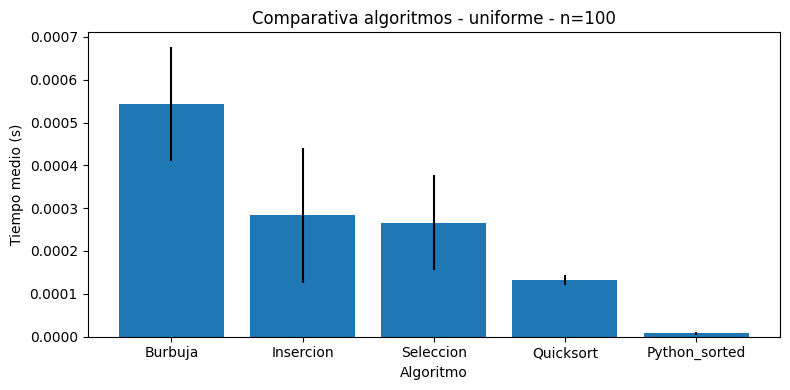

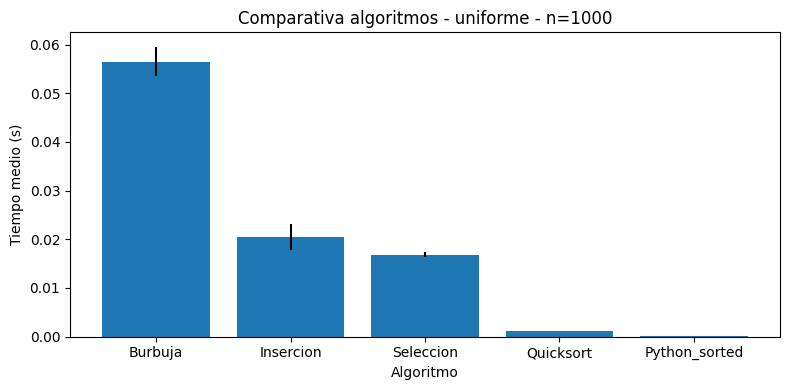

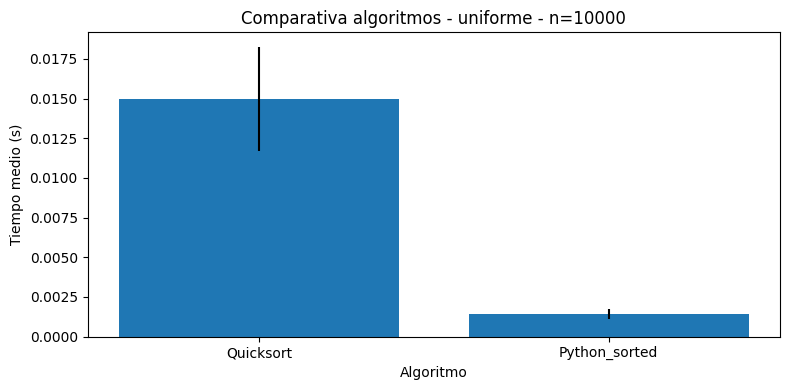

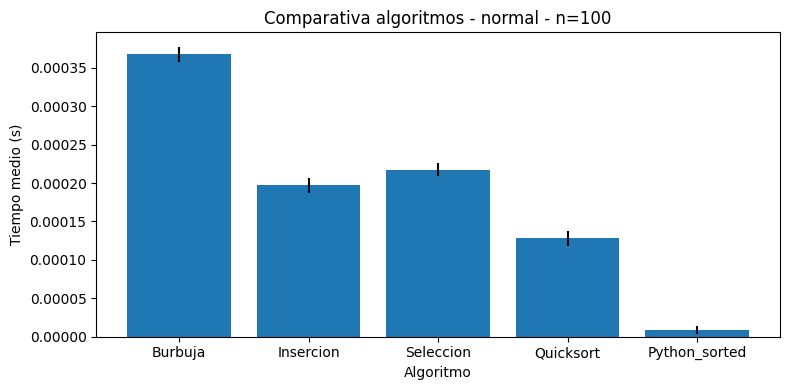

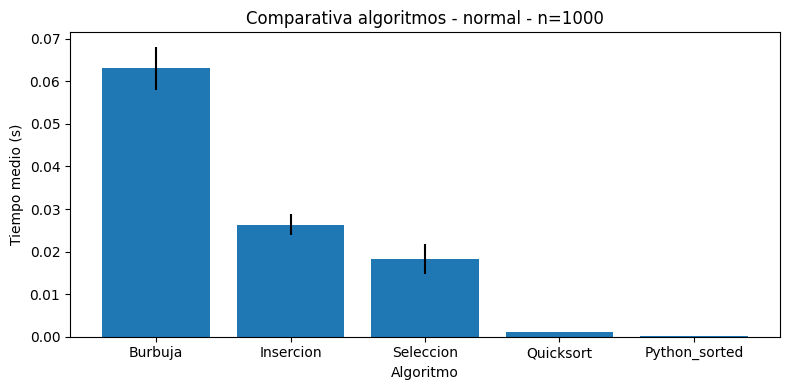

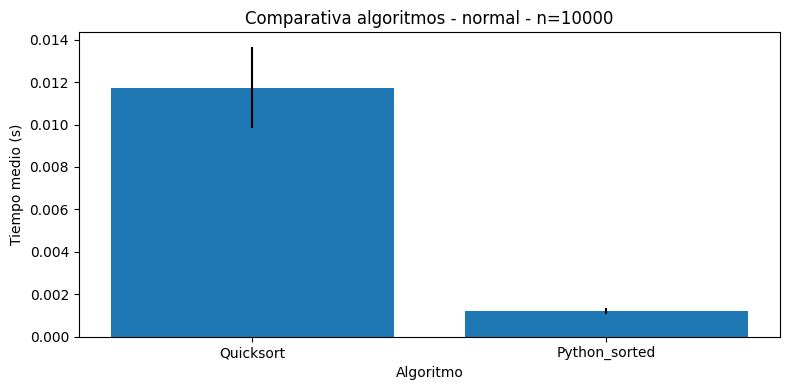

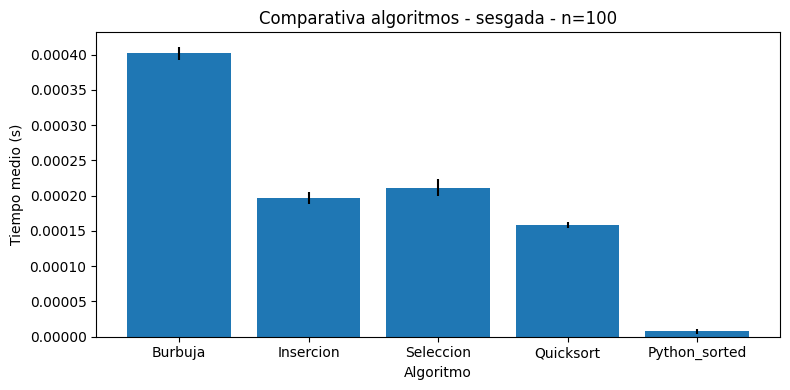

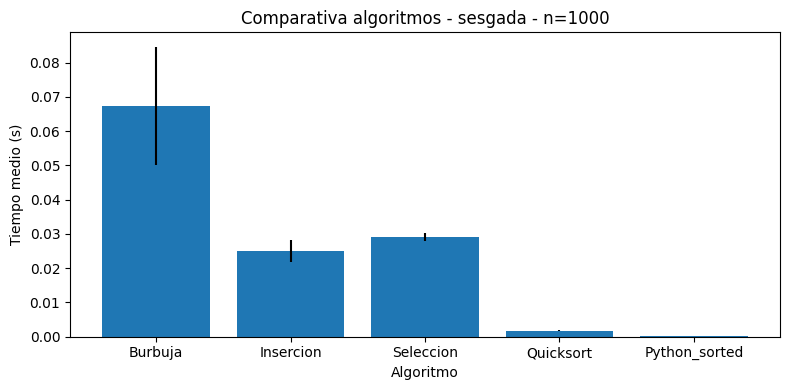

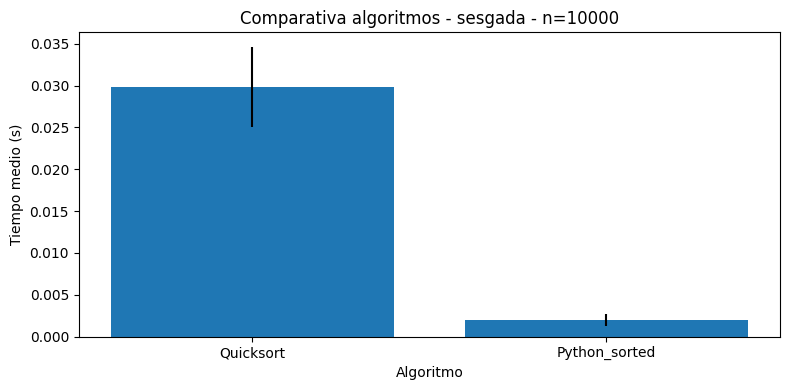

In [7]:

# Función auxiliar para graficar barras (un gráfico por tamaño)
def graficar_por_tamano(results, distribucion, n):
    algs = []
    tiempos = []
    errores = []
    for nombre in algoritmos_orden.keys():
        val = results.get((distribucion,n), {}).get('orden', {}).get(nombre, None)
        if val is None:
            continue
        t_mean, t_std = val
        algs.append(nombre)
        tiempos.append(t_mean)
        errores.append(t_std)
    if not algs:
        print(f'No hay datos de ordenamiento para {distribucion} n={n} (probablemente SKIPPED).')
        return
    plt.figure(figsize=(8,4))
    plt.bar(algs, tiempos, yerr=errores)
    plt.title(f'Comparativa algoritmos - {distribucion} - n={n}')
    plt.ylabel('Tiempo medio (s)')
    plt.xlabel('Algoritmo')
    plt.tight_layout()
    plt.show()

# Dibujar gráficos
for dist in distribuciones:
    for n in tamanos:
        graficar_por_tamano(results, dist, n)



#. Gráficas comparativas de búsqueda



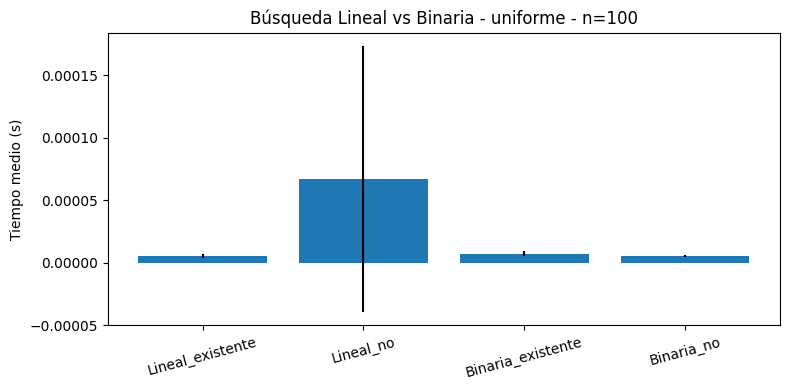

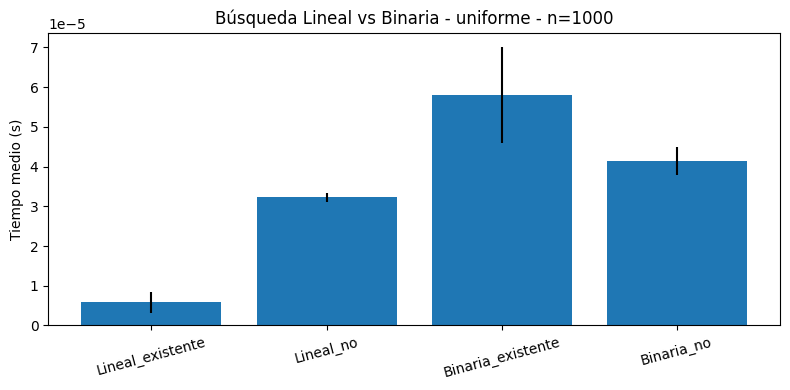

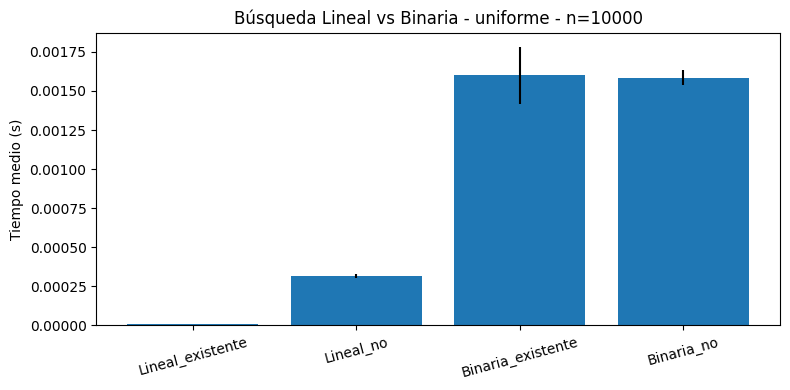

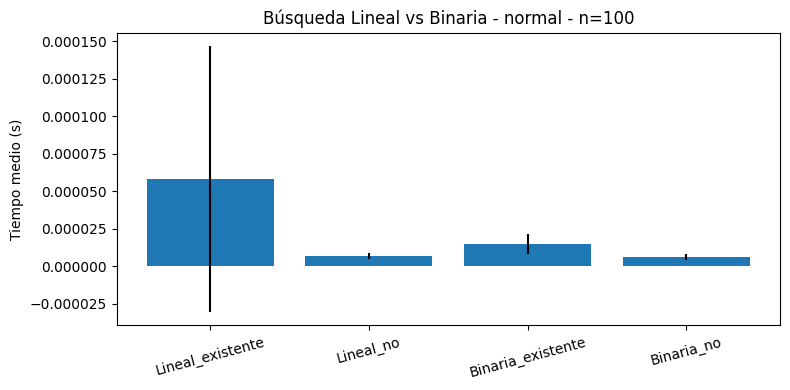

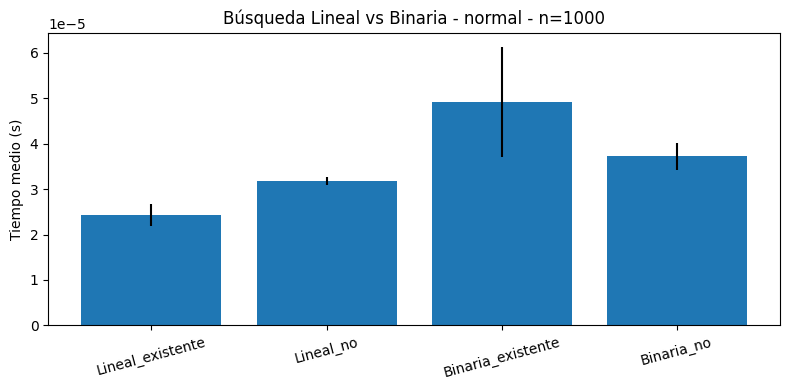

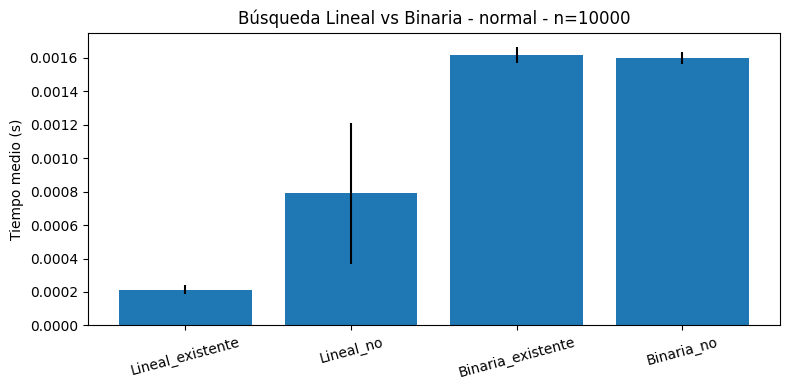

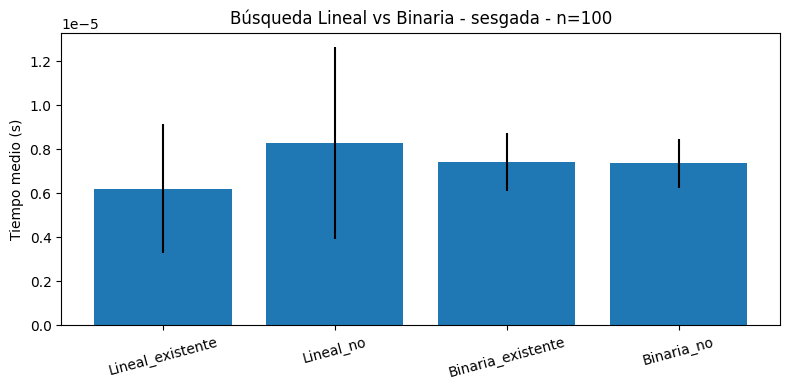

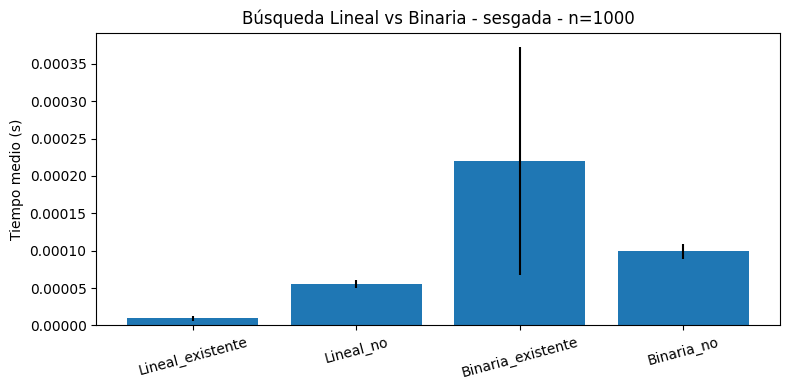

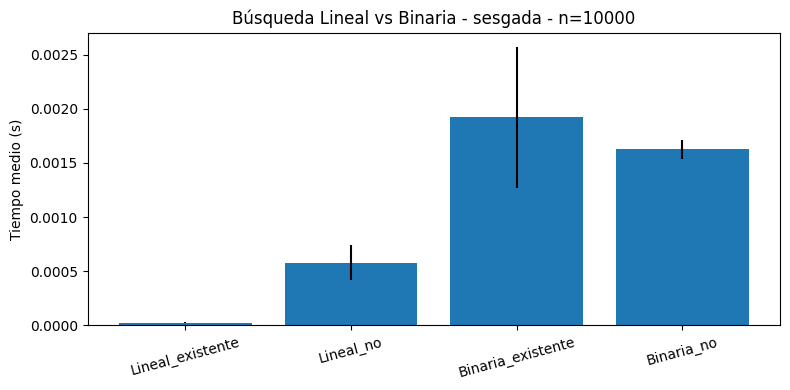

In [8]:

def graficar_busqueda(results, distribucion, n):
    labels = []
    tiempos = []
    errores = []
    keys = ['Lineal_existente','Lineal_no','Binaria_existente','Binaria_no']
    for k in keys:
        val = results.get((distribucion,n), {}).get('busqueda', {}).get(k, None)
        if val is None:
            continue
        labels.append(k)
        tiempos.append(val[0])
        errores.append(val[1])
    if not labels:
        print(f'No hay datos de búsqueda para {distribucion} n={n}.')
        return
    plt.figure(figsize=(8,4))
    plt.bar(labels, tiempos, yerr=errores)
    plt.title(f'Búsqueda Lineal vs Binaria - {distribucion} - n={n}')
    plt.ylabel('Tiempo medio (s)')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

for dist in distribuciones:
    for n in tamanos:
        graficar_busqueda(results, dist, n)



## 8. Guardar resultados y carpeta de entrega
Se crea una carpeta `Proyecto_Algoritmos_TuNombre` (puedes cambiar el nombre) y se guardan los resultados en CSV y las figuras si quieres.


In [9]:

import os
import pandas as pd

carpeta = 'Proyecto_Algoritmos_TuNombre'
os.makedirs(carpeta, exist_ok=True)
# Guardar DataFrame
df_results.to_csv(os.path.join(carpeta, 'resultados_experimentos.csv'), index=False)
print('Resultados guardados en:', os.path.join(carpeta, 'resultados_experimentos.csv'))

# Guardar una copia del notebook (opcional en local, Colab guarda en Drive si lo usas)


Resultados guardados en: Proyecto_Algoritmos_TuNombre/resultados_experimentos.csv



## 9. Conclusiones y recomendaciones finales

- Para datasets pequeños (n ≤ 100) los algoritmos simples (Inserción, Selección) son suficientes.  
- Para datos medianos/grandes, usar `quicksort` o `sorted()` (timsort) es más efectivo.  
- La búsqueda binaria es muy superior a la lineal en arreglos ordenados (O(log n) frente a O(n)).  
- Siempre generar datasets representativos (uniforme, normal, sesgado) para entender el comportamiento real del algoritmo.

---
**Entrega:** sube este notebook a Google Colab, ejecuta las celdas y adjunta la carpeta `Proyecto_Algoritmos_TuNombre` con `resultados_experimentos.csv` como evidencia.
